In [ ]:
!pip install ultralytics tensorflow opencv-python-headless pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!nvidia-smi

Fri Sep 12 06:48:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvidia-smi  # check GPU
!pip install ultralytics opencv-python matplotlib

Fri Sep 12 06:54:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import cv2
import numpy as np
import random
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
OUT = "/content/fashion_yolo"
os.makedirs(f"{OUT}/images/train", exist_ok=True)
os.makedirs(f"{OUT}/images/val", exist_ok=True)
os.makedirs(f"{OUT}/labels/train", exist_ok=True)
os.makedirs(f"{OUT}/labels/val", exist_ok=True)

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

def bbox_from_mask(img, th=10):
    """Find bounding box from non-zero pixels"""
    pts = cv2.findNonZero((img > th).astype(np.uint8))
    if pts is None:
        return 0,0,img.shape[1], img.shape[0]
    x,y,w,h = cv2.boundingRect(pts)
    return x,y,w,h

def save_yolo(img, label, split, idx):
    # Resize to 128x128
    img = cv2.resize(img, (128,128))
    x,y,w,h = bbox_from_mask(img)
    H,W = img.shape
    cx, cy = (x+w/2)/W, (y+h/2)/H
    nw, nh = w/W, h/H

    img_path = f"{OUT}/images/{split}/{idx}.jpg"
    label_path = f"{OUT}/labels/{split}/{idx}.txt"

    cv2.imwrite(img_path, img)
    with open(label_path, "w") as f:
        f.write(f"{label} {cx} {cy} {nw} {nh}\n")

# Save 5000 train, 1000 val
for i in range(5000):
    save_yolo(x_train[i], int(y_train[i]), "train", i)

for i in range(1000):
    save_yolo(x_test[i], int(y_test[i]), "val", i)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

with open(f"{OUT}/fashion.yaml", "w") as f:
    f.write(f"""
path: {OUT}
train: images/train
val: images/val

names:
""")
    for i, name in enumerate(labels):
        f.write(f"  {i}: {name}\n")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # small YOLO model
model.train(data=f"{OUT}/fashion.yaml", epochs=5, imgsz=128)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.198 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fashion_yolo/fashion.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, ke

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b6feb7357f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
results = model.predict(source=f"{OUT}/images/val", imgsz=128, save=True)


image 1/1000 /content/fashion_yolo/images/val/0.jpg: 128x128 1 Ankle boot, 9.8ms
image 2/1000 /content/fashion_yolo/images/val/1.jpg: 128x128 1 Pullover, 6.0ms
image 3/1000 /content/fashion_yolo/images/val/10.jpg: 128x128 1 Coat, 7.6ms
image 4/1000 /content/fashion_yolo/images/val/100.jpg: 128x128 1 Dress, 8.5ms
image 5/1000 /content/fashion_yolo/images/val/101.jpg: 128x128 1 Coat, 6.4ms
image 6/1000 /content/fashion_yolo/images/val/102.jpg: 128x128 1 Sneaker, 6.1ms
image 7/1000 /content/fashion_yolo/images/val/103.jpg: 128x128 1 Pullover, 1 Shirt, 5.7ms
image 8/1000 /content/fashion_yolo/images/val/104.jpg: 128x128 1 Sneaker, 6.1ms
image 9/1000 /content/fashion_yolo/images/val/105.jpg: 128x128 1 Bag, 6.2ms
image 10/1000 /content/fashion_yolo/images/val/106.jpg: 128x128 1 Sandal, 6.1ms
image 11/1000 /content/fashion_yolo/images/val/107.jpg: 128x128 1 Sneaker, 5.9ms
image 12/1000 /content/fashion_yolo/images/val/108.jpg: 128x128 1 Ankle boot, 6.0ms
image 13/1000 /content/fashion_yolo/i

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


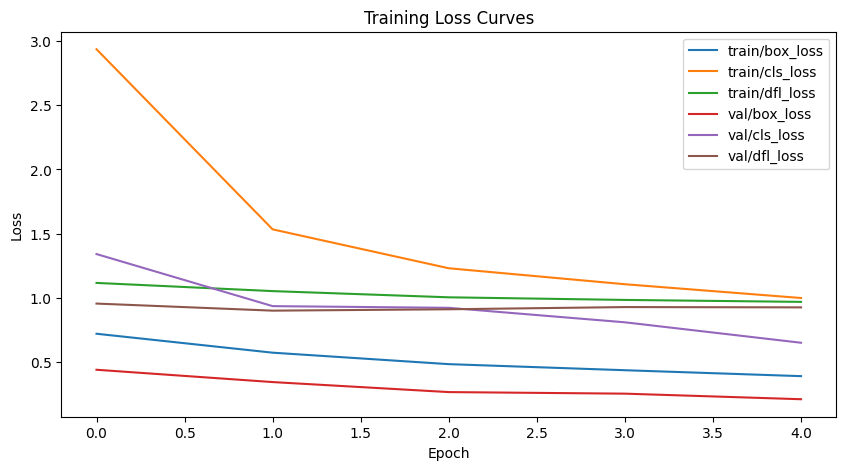

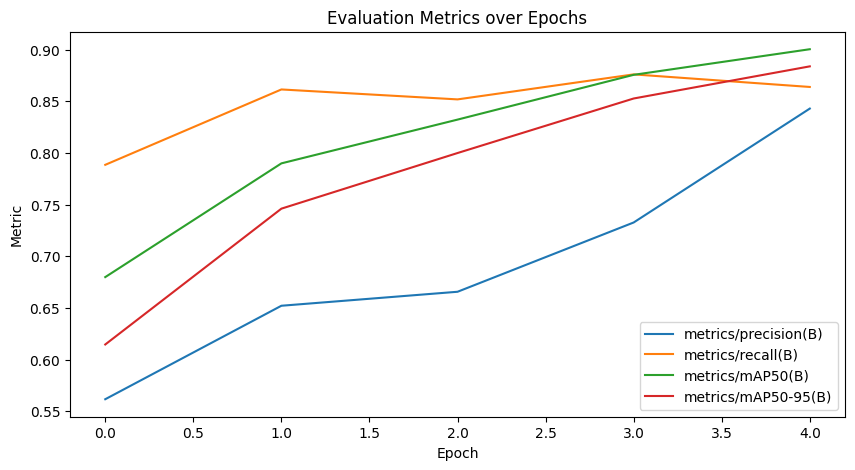

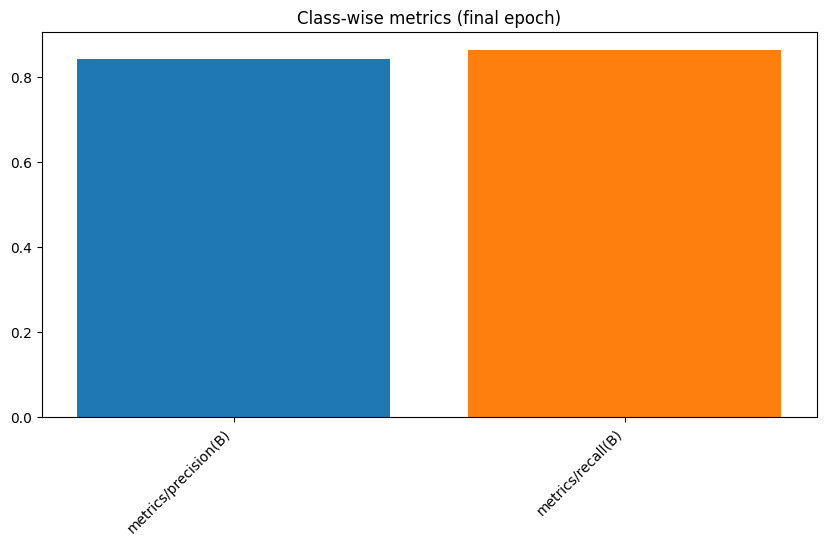

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("runs/detect/train/results.csv")
print("Available columns:", df.columns.tolist())

# 1️⃣ Plot all loss curves
loss_cols = [c for c in df.columns if "loss" in c]
plt.figure(figsize=(10,5))
for col in loss_cols:
    plt.plot(df.index, df[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

# 2️⃣ Plot all metric curves (precision, recall, mAP)
metric_cols = [c for c in df.columns if "metrics" in c]
plt.figure(figsize=(10,5))
for col in metric_cols:
    plt.plot(df.index, df[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Evaluation Metrics over Epochs")
plt.legend()
plt.show()

# 3️⃣ Plot class accuracy/precision if available
class_metric_cols = [c for c in df.columns if "precision" in c or "recall" in c]
if class_metric_cols:
    df_last = df.iloc[-1]
    plt.figure(figsize=(10,5))
    for col in class_metric_cols:
        plt.bar(col, df_last[col])
    plt.xticks(rotation=45, ha="right")
    plt.title("Class-wise metrics (final epoch)")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check if YOLO saved PR curves (PNG)
import os
pr_file = "runs/detect/train/pr_curves.png"
if os.path.exists(pr_file):
    from PIL import Image
    img = Image.open(pr_file)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision-Recall Curve (saved by YOLO)")
    plt.show()
else:
    print("No PR curve image found, maybe training was short or not logged.")

No PR curve image found, maybe training was short or not logged.


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")  # load best trained model
metrics = model.val(data=f"{OUT}/fashion.yaml", imgsz=128, split="val")

Ultralytics 8.3.198 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 146.5±33.0 MB/s, size: 3.1 KB)
val: Scanning /content/fashion_yolo/labels/val.cache... 1000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 13.9it/s 4.5s
                   all       1000       1000      0.843      0.864      0.901      0.884
               T-shirt        107        107       0.71      0.888      0.891      0.888
               Trouser        105        105      0.993       0.99      0.995      0.971
              Pullover        111        111      0.811      0.892      0.917      0.916
                 Dress         93         93      0.841      0.828      0.902      0.892
                  Coat        115        115  

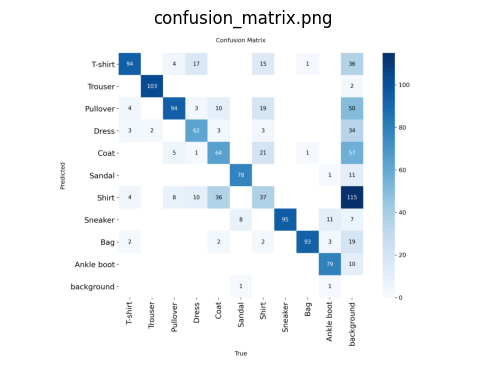

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for f in ["pr_curves.png", "confusion_matrix.png", "F1_curve.png", "results.png"]:
    file_path = f"runs/detect/val/{f}"
    if os.path.exists(file_path):
        img = Image.open(file_path)
        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f)
        plt.show()

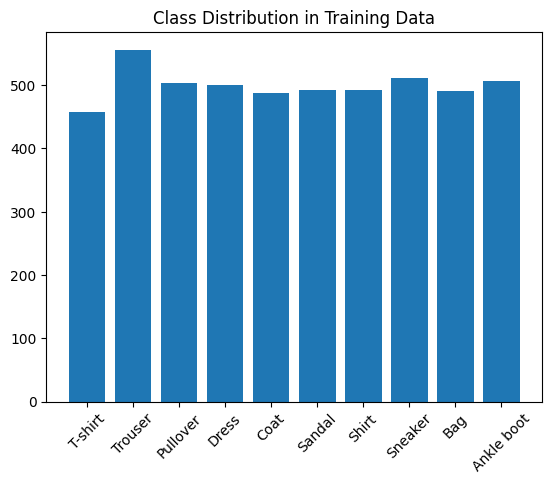

In [ ]:
import os

train_labels = f"{OUT}/labels/train"
counts = [0]*10
for file in os.listdir(train_labels):
    with open(os.path.join(train_labels, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            counts[cls]+=1

plt.bar(range(10), counts)
plt.xticks(range(10), labels, rotation=45)
plt.title("Class Distribution in Training Data")
plt.show()

In [ ]:
from ultralytics import YOLO

# Load best trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Run prediction on validation images
results = model.predict(source=f"{OUT}/images/val", imgsz=128, save=True)

print("Predictions saved in:", results[0].save_dir)


image 1/1000 /content/fashion_yolo/images/val/0.jpg: 128x128 1 Ankle boot, 8.2ms
image 2/1000 /content/fashion_yolo/images/val/1.jpg: 128x128 1 Pullover, 5.5ms
image 3/1000 /content/fashion_yolo/images/val/10.jpg: 128x128 1 Coat, 5.4ms
image 4/1000 /content/fashion_yolo/images/val/100.jpg: 128x128 1 Dress, 5.7ms
image 5/1000 /content/fashion_yolo/images/val/101.jpg: 128x128 1 Coat, 5.4ms
image 6/1000 /content/fashion_yolo/images/val/102.jpg: 128x128 1 Sneaker, 5.4ms
image 7/1000 /content/fashion_yolo/images/val/103.jpg: 128x128 1 Pullover, 1 Shirt, 5.9ms
image 8/1000 /content/fashion_yolo/images/val/104.jpg: 128x128 1 Sneaker, 6.0ms
image 9/1000 /content/fashion_yolo/images/val/105.jpg: 128x128 1 Bag, 5.4ms
image 10/1000 /content/fashion_yolo/images/val/106.jpg: 128x128 1 Sandal, 5.9ms
image 11/1000 /content/fashion_yolo/images/val/107.jpg: 128x128 1 Sneaker, 8.4ms
image 12/1000 /content/fashion_yolo/images/val/108.jpg: 128x128 1 Ankle boot, 5.9ms
image 13/1000 /content/fashion_yolo/i

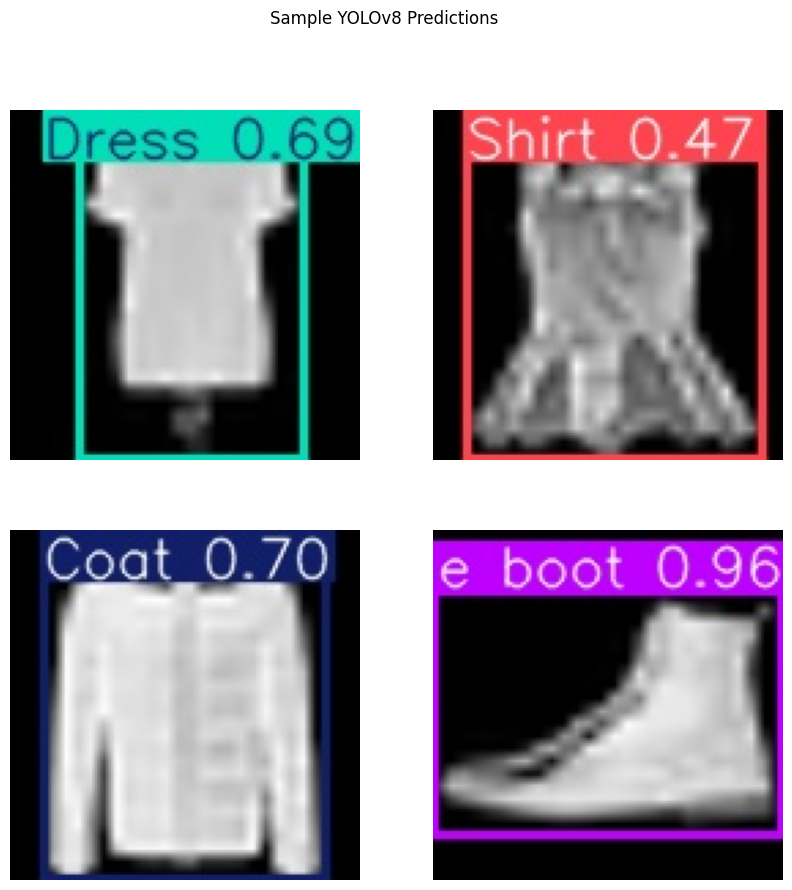

In [ ]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = results[0].save_dir  # auto-detect latest prediction folder
sample_images = random.sample(os.listdir(pred_dir), 4)

plt.figure(figsize=(10,10))
for i,img in enumerate(sample_images):
    plt.subplot(2,2,i+1)
    plt.imshow(Image.open(os.path.join(pred_dir,img)))
    plt.axis("off")
plt.suptitle("Sample YOLOv8 Predictions")
plt.show()

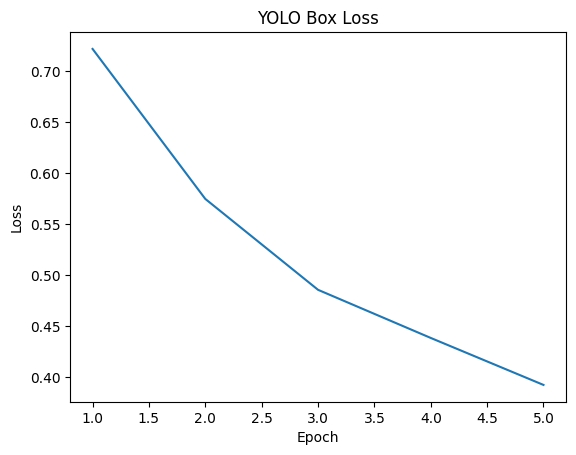

In [ ]:
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO Box Loss")
plt.show()

In [ ]:
# 1. Create fashion.yaml file
fashion_yaml = """
# Fashion-MNIST YOLO dataset configuration

# Paths
train: ./datasets/fashion/train/images
val: ./datasets/fashion/val/images
test: ./datasets/fashion/test/images  # optional

# Classes
names:
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot
"""

# 2. Save it into your working directory
with open("fashion.yaml", "w") as f:
    f.write(fashion_yaml)

print("✅ fashion.yaml file saved successfully!")

✅ fashion.yaml file saved successfully!


In [ ]:
!ls

fashion.yaml  runs  sample_data  yolov8n.pt


In [ ]:
import os
from torchvision.datasets import FashionMNIST
from PIL import Image
import torchvision.transforms as transforms

os.makedirs("datasets/fashion/train/images", exist_ok=True)
os.makedirs("datasets/fashion/train/labels", exist_ok=True)
os.makedirs("datasets/fashion/val/images", exist_ok=True)
os.makedirs("datasets/fashion/val/labels", exist_ok=True)

# Train dataset
train_dataset = FashionMNIST(root="./fashion_mnist", train=True, download=True, transform=transforms.ToTensor())
for i, (img, label) in enumerate(train_dataset):
    img_path = f"datasets/fashion/train/images/{i}.jpg"
    Image.fromarray((img.squeeze().numpy()*255).astype("uint8")).save(img_path)
    with open(f"datasets/fashion/train/labels/{i}.txt", "w") as f:
        f.write(f"{label} 0.5 0.5 1.0 1.0\n")

# Validation dataset
val_dataset = FashionMNIST(root="./fashion_mnist", train=False, download=True, transform=transforms.ToTensor())
for i, (img, label) in enumerate(val_dataset):
    img_path = f"datasets/fashion/val/images/{i}.jpg"
    Image.fromarray((img.squeeze().numpy()*255).astype("uint8")).save(img_path)
    with open(f"datasets/fashion/val/labels/{i}.txt", "w") as f:
        f.write(f"{label} 0.5 0.5 1.0 1.0\n")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [ ]:
!pip install ultralytics

from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

# Load YOLOv8 Nano
model = YOLO("yolov8n.pt")

# Update loss function
# if isinstance(model.model, DetectionModel):
#     model.model.criterion.box = "ciou"
#     model.model.criterion.cls = "bce"
#     model.model.criterion.obj = "bce"

# Train
model.train(
    data="/content/fashion.yaml",
    epochs=10,
    imgsz=64,
    optimizer="SGD",
    lr0=0.01
)

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fashion.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x793ce1a85910>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO("runs/detect/train3/weights/best.pt")

# Run validation to generate metrics and confusion matrix
metrics = model.val(data="/content/fashion.yaml", imgsz=64, split="val")

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.5±15.5 MB/s, size: 0.6 KB)
val: Scanning /content/datasets/fashion/val/labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 13.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 14.8it/s 42.1s
                   all      10000      10000      0.765      0.848       0.88      0.772
           T-shirt/top       1000       1000       0.74       0.83       0.86      0.758
               Trouser       1000       1000       0.93      0.979      0.988      0.793
              Pullover       1000       1000      0.619      0.893      0.842      0.763
                 Dress       1000       1000      0.857       0.79       0.91      0.783
                  Coat       1000   

Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 41.2±16.7 MB/s, size: 0.6 KB)
val: Scanning /content/datasets/fashion/val/labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 14.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 15.3it/s 40.9s
                   all      10000      10000      0.765      0.848       0.88      0.772
           T-shirt/top       1000       1000       0.74       0.83       0.86      0.758
               Trouser       1000       1000       0.93      0.979      0.988      0.793
              Pullover       1000       1000      0.619      0.893      0.842      0.763
                 Dress       1000       1000      0.857       0.79       0.91      0.783
                  Coat       1000   

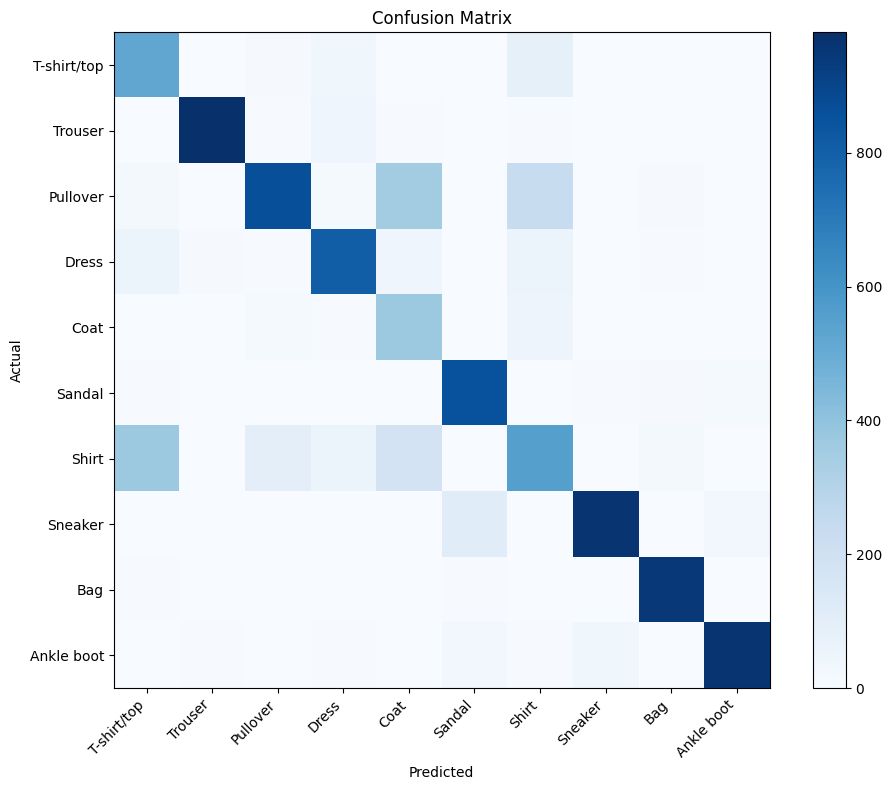

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ------------------------
# 1. Load trained model
# ------------------------
model = YOLO("runs/detect/train3/weights/best.pt")

# ------------------------
# 2. Run validation
# ------------------------
results = model.val(data="/content/fashion.yaml", plots=True)  # saves confusion_matrix.png automatically

# ------------------------
# 3. Extract predictions
# ------------------------
# Access the confusion matrix data directly from the results object
cm_data = results.confusion_matrix.matrix

# Exclude the last row/column if it represents background
if cm_data.shape[0] > len(model.names):
    cm_data = cm_data[:len(model.names), :len(model.names)]

# Extract true and predicted labels from the confusion matrix data
# The confusion matrix rows are true labels, columns are predicted labels
y_true = []
y_pred = []
for true_label in range(cm_data.shape[0]):
    for pred_label in range(cm_data.shape[1]):
        count = cm_data[true_label, pred_label]
        y_true.extend([true_label] * int(count))
        y_pred.extend([pred_label] * int(count))


# ------------------------
# 4. Confusion Matrix
# ------------------------
# Use the extracted data to generate the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(model.names))))
print("Confusion Matrix:\n", cm)

# ------------------------
# 5. Accuracy, Precision, Recall, F1
# ------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(model.names.values())))

# Overall accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Overall Accuracy: {acc:.4f}")

# ------------------------
# 6. Plot Confusion Matrix
# ------------------------
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(list(range(len(model.names))), list(model.names.values()), rotation=45, ha="right")
plt.yticks(list(range(len(model.names))), list(model.names.values()))
plt.tight_layout()
plt.show()